<a href="https://colab.research.google.com/github/Sampritisahoo/DEEP_LEARNING/blob/main/metric_claculation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Step 1: Import libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, learning_curve, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, roc_curve, auc

In [ ]:
# ---------------------------------------------------
# Step 2: Load dataset
# ---------------------------------------------------
data = load_breast_cancer()
X = data.data
y = data.target

In [ ]:
# ---------------------------------------------------
# Step 3: Split dataset into training and testing
# ---------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# ---------------------------------------------------
# Step 4: Scale the data
# Scaling improves convergence of Logistic Regression
# ---------------------------------------------------
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# ---------------------------------------------------
# Step 5: Train Logistic Regression model
# Increased max_iter to ensure convergence
# ---------------------------------------------------
model = LogisticRegression(max_iter=10000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=10000)

In [ ]:
# ---------------------------------------------------
# Step 6: Predictions
# ---------------------------------------------------
y_pred = model.predict(X_test)

In [ ]:
# ---------------------------------------------------
# Step 7: Evaluation Metrics
# ---------------------------------------------------
print("\n--- Evaluation Metrics ---")

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))


--- Evaluation Metrics ---
Accuracy : 0.9736842105263158
Precision: 0.9722222222222222
Recall   : 0.9859154929577465
F1 Score : 0.9790209790209791


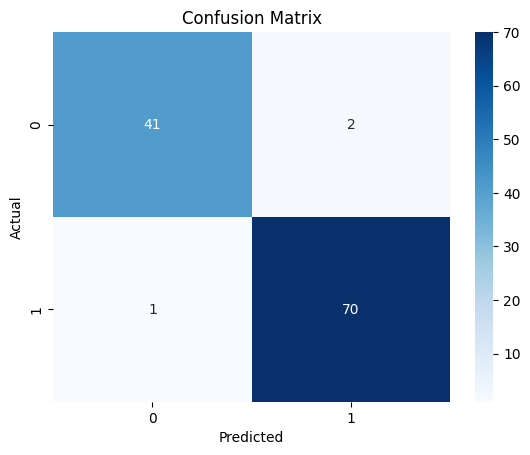

In [ ]:
# ---------------------------------------------------
# Step 8: Confusion Matrix
# ---------------------------------------------------
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

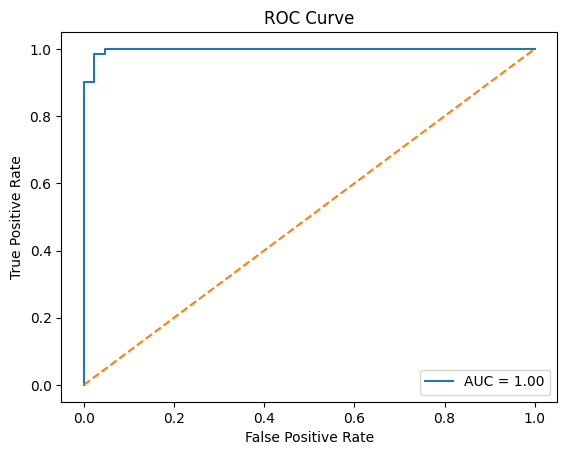

In [ ]:
# ---------------------------------------------------
# Step 9: ROC Curve
# ---------------------------------------------------
y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label="AUC = %0.2f" % roc_auc)
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

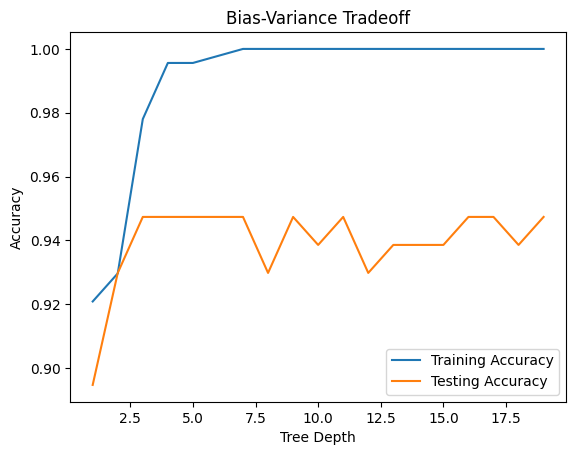

In [ ]:
# ---------------------------------------------------
# Step 10: Bias-Variance Tradeoff
# ---------------------------------------------------
train_scores = []
test_scores = []

depths = range(1,20)

for d in depths:

    tree = DecisionTreeClassifier(max_depth=d)

    tree.fit(X_train, y_train)

    train_scores.append(tree.score(X_train,y_train))
    test_scores.append(tree.score(X_test,y_test))


plt.figure()
plt.plot(depths, train_scores, label="Training Accuracy")
plt.plot(depths, test_scores, label="Testing Accuracy")
plt.xlabel("Tree Depth")
plt.ylabel("Accuracy")
plt.title("Bias-Variance Tradeoff")
plt.legend()
plt.show()

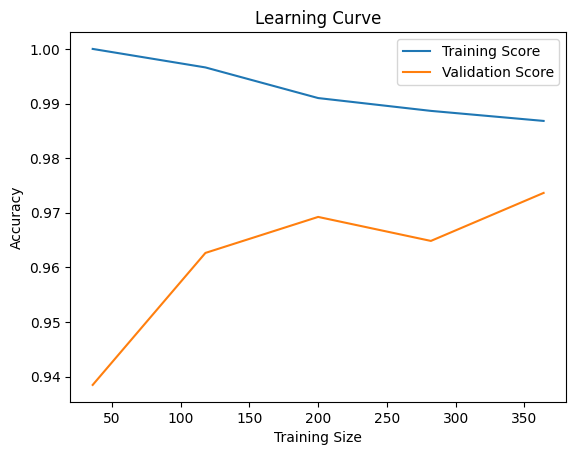

In [ ]:
#---------------------------------------------------
# Step 11: Learning Curve
# ---------------------------------------------------
train_sizes, train_scores, test_scores = learning_curve(
    LogisticRegression(max_iter=10000),
    X_train,
    y_train,
    cv=5,
    train_sizes=np.linspace(0.1,1.0,5)
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.figure()
plt.plot(train_sizes, train_mean, label="Training Score")
plt.plot(train_sizes, test_mean, label="Validation Score")
plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve")
plt.legend()
plt.show()

In [ ]:
# ---------------------------------------------------
# Step 12: Hyperparameter Tuning
# ---------------------------------------------------
param_grid = {'C':[0.01,0.1,1,10]}

grid = GridSearchCV(
    LogisticRegression(max_iter=10000),
    param_grid,
    cv=5
)

grid.fit(X_train,y_train)

print("\n--- Hyperparameter Tuning ---")
print("Best Parameter:", grid.best_params_)
print("Best CV Score :", grid.best_score_)


--- Hyperparameter Tuning ---
Best Parameter: {'C': 10}
Best CV Score : 0.9758241758241759
